In [1]:
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2 
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.models import Model
import numpy as np
import matplotlib.pyplot as plt
import os
import glob as gb
import cv2
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Load MobileNetV2 with pre-trained weights (on ImageNet)
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(96, 96, 3), alpha=0.35)

# Freeze the layers of the base model so they aren't updated during the training
base_model.trainable = False

In [2]:
# Add a global average pooling layer
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(1, activation='sigmoid')(x)  # Use 'sigmoid' for binary classification
# Create the final model
model = Model(inputs=base_model.input, outputs=x)
# Compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [3]:
# Get the current working directory (main directory of the script)
main_dir = os.getcwd()

# Construct the paths relative to the main directory
train_path = os.path.join(main_dir, 'dataset', 'train')
test_path = os.path.join(main_dir, 'dataset', 'test')
val_path = os.path.join(main_dir, 'dataset', 'val')

In [4]:
# Get the current working directory
current_dir = os.getcwd()

# Go one step back
main_dir = os.path.dirname(current_dir)

In [5]:

# Construct the paths relative to the main directory
train_path = os.path.join(main_dir, 'dataset', 'train')
test_path = os.path.join(main_dir, 'dataset', 'test')
val_path = os.path.join(main_dir, 'dataset', 'val')
for folder in os.listdir(train_path):
    images=gb.glob(pathname=train_path + '/' +folder+'/*')
    print(f'for training data, we found {len(images)} in folder {folder}')
for folder in os.listdir(test_path):
    images=gb.glob(pathname=test_path + '/' +folder+'/*')
    print(f'for testing data, we found {len(images)} in folder {folder}')
for folder in os.listdir(val_path):
    images=gb.glob(pathname=val_path + '/' +folder+'/*')
    print(f'for val data, we found {len(images)} in folder {folder}')
code={"clean":0,"dirty":1}

for training data, we found 747 in folder clean
for training data, we found 800 in folder dirty
for testing data, we found 100 in folder clean
for testing data, we found 100 in folder dirty
for val data, we found 100 in folder clean
for val data, we found 100 in folder dirty


In [6]:
# size=[]

# for folder in os.listdir(train_path):
#     images=gb.glob(pathname=train_path + '/' +folder+'/*.jpg')
#     for img in images:
#       image=plt.imread(img)
#       size.append(image.shape)
#

In [7]:
def normalize_image(image):
    """Normalize the image to range [-1, 1]."""
    image = image.astype(np.float32)  # Convert to float32 for division
    image = (image / 127.5) - 1.0  # Normalize to [-1, 1]
    return image

In [8]:
x_train = []
y_train = []

# Load and normalize training data
for folder in os.listdir(train_path):
    images = gb.glob(pathname=train_path + '/' + folder + '/*')
    
    for img in images:
        try:
            image = cv2.imread(img)
            if image is not None:
                image = cv2.resize(image, (96, 96))  # Resize to (96, 96)
                image = normalize_image(image)  # Normalize to [-1, 1]
                x_train.append(image)
                y_train.append(code[folder])
        except Exception as e:
            print(f"Error loading image {img}: {e}")

x_test = []
y_test = []

# Load and normalize testing data
for folder in os.listdir(test_path):
    images = gb.glob(pathname=test_path + '/' + folder + '/*')
    
    for img in images:
        try:
            image = cv2.imread(img)
            if image is not None:
                image = cv2.resize(image, (96, 96))  # Resize to (96, 96)
                image = normalize_image(image)  # Normalize to [-1, 1]
                x_test.append(image)
                y_test.append(code[folder])
        except Exception as e:
            print(f"Error loading image {img}: {e}")

x_val = []
y_val = []

# Load and normalize validation data
for folder in os.listdir(val_path):
    images = gb.glob(pathname=val_path + '/' + folder + '/*')
    
    for img in images:
        try:
            image = cv2.imread(img)
            if image is not None:
                image = cv2.resize(image, (96, 96))  # Resize to (96, 96)
                image = normalize_image(image)  # Normalize to [-1, 1]
                x_val.append(image)
                y_val.append(code[folder])
        except Exception as e:
            print(f"Error loading image {img}: {e}")


In [9]:
# Converting lists to numpy arrays for training
x_train = np.array(x_train)
y_train = np.array(y_train)
x_test = np.array(x_test)
y_test = np.array(y_test)
x_val = np.array(x_val)
y_val = np.array(y_val)

print(f"Training data shape: {x_train.shape}, Labels shape: {y_train.shape}")
print(f"Testing data shape: {x_test.shape}, Labels shape: {y_test.shape}")
print(f"Validation data shape: {x_val.shape}, Labels shape: {y_val.shape}")

Training data shape: (1546, 96, 96, 3), Labels shape: (1546,)
Testing data shape: (200, 96, 96, 3), Labels shape: (200,)
Validation data shape: (200, 96, 96, 3), Labels shape: (200,)


In [10]:
train_generator = ImageDataGenerator(
    rotation_range=5,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.1,
    zoom_range=[0.8, 1.2],
    horizontal_flip=True,
    brightness_range=(0.5, 1.2),
)

val_generator = ImageDataGenerator(
    rotation_range=5,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.1,
    zoom_range=[0.8, 1.2],
    horizontal_flip=True,
    brightness_range=(0.5, 1.2),

)

test_generator = ImageDataGenerator(

)
train_generator.fit(x_train)
val_generator.fit(x_val)
test_generator.fit(x_test)
x_train_generator=train_generator.flow(x_train,y_train,batch_size=32)
x_valid_generator=val_generator.flow(x_val,y_val,batch_size=32)
x_test_generator=test_generator.flow(x_test,y_test,batch_size=32)

In [11]:
# Define callbacks for early stopping and learning rate reduction
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
learning_rate_reduction = ReduceLROnPlateau(monitor='val_accuracy', patience = 5, verbose=1,factor=0.5, min_lr=0.00001)
his=model.fit(x_train_generator,epochs=50,validation_data=x_valid_generator,verbose=1,callbacks=[early_stopping,learning_rate_reduction])

Epoch 1/50


d:\Smart bin\.venv\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


25/25 ━━━━━━━━━━━━━━━━━━━━ 10s 206ms/step - accuracy: 0.6364 - loss: 0.6262 - val_accuracy: 0.8700 - val_loss: 0.3639 - learning_rate: 0.0010
Epoch 2/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 128ms/step - accuracy: 0.8459 - loss: 0.3402 - val_accuracy: 0.8950 - val_loss: 0.2560 - learning_rate: 0.0010
Epoch 3/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 127ms/step - accuracy: 0.8753 - loss: 0.2856 - val_accuracy: 0.9000 - val_loss: 0.2349 - learning_rate: 0.0010
Epoch 4/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 126ms/step - accuracy: 0.9095 - loss: 0.2418 - val_accuracy: 0.9250 - val_loss: 0.2218 - learning_rate: 0.0010
Epoch 5/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 120ms/step - accuracy: 0.9163 - loss: 0.2333 - val_accuracy: 0.9050 - val_loss: 0.2219 - learning_rate: 0.0010
Epoch 6/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 121ms/step - accuracy: 0.9128 - loss: 0.2408 - val_accuracy: 0.9300 - val_loss: 0.1850 - learning_rate: 0.0010
Epoch 7/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 116ms/step - accuracy: 0.9300 - loss: 0.1941 - val_accura

In [12]:
model.save('trash_classifier_mobilenetv28.h5')

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.9457 - loss: 0.1922
Test accuracy: 94.50%


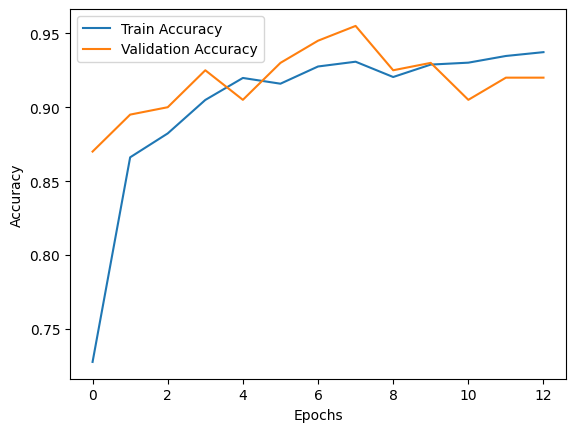

In [13]:
test_loss, test_accuracy = model.evaluate(x_test_generator)
print(f'Test accuracy: {test_accuracy * 100:.2f}%')

# Optional: Plot training history
plt.plot(his.history['accuracy'], label='Train Accuracy')
plt.plot(his.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [14]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 96, 96, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 48, 48,    │        432 │ input_layer[0][0] │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 48, 48,    │         64 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 48, 48,    │          0 │ bn_Conv1[0][0]    │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 48, 48,    │        144 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 48, 48,    │         64 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 48, 48,    │          0 │ expanded_conv_de… │
│ (ReLU)              │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 48, 48, 8) │        128 │ expanded_conv_de… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 48, 48, 8) │         32 │ expanded_conv_pr… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 48, 48,    │        384 │ expanded_conv_pr… │
│ (Conv2D)            │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 48, 48,    │        192 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 48, 48,    │          0 │ block_1_expand_B… │
│ (ReLU)              │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 49, 49,    │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 24, 24,    │        432 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 24, 24,    │        192 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 24, 24,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 24, 24, 8) │        384 │ block_1_depthwis

 Total params: 414,053 (1.58 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 410,208 (1.56 MB)

 Optimizer params: 2,564 (10.02 KB)

In [15]:
from tensorflow.keras.models import load_model
model1 = load_model('trash_classifier_mobilenetv28.h5')

In [16]:
test_loss, test_accuracy = model1.evaluate(x_test_generator)
print(f'Test accuracy: {test_accuracy * 100:.2f}%')

4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step - accuracy: 0.9415 - loss: 0.1943
Test accuracy: 94.50%


In [17]:

model1_pred=model1.predict(x_test)
model1_pred_classes = (model1_pred > 0.5).astype(int)  # Use a threshold of 0.5
from sklearn.metrics import classification_report,confusion_matrix
cm = confusion_matrix(y_test,model1_pred_classes)
# Generate classification report
report = classification_report(y_test, model1_pred_classes)

print("Confusion Matrix:\n", cm)
print("\nClassification Report:\n", report)

7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 168ms/step
Confusion Matrix:
 [[94  6]
 [ 5 95]]

Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.94      0.94       100
           1       0.94      0.95      0.95       100

    accuracy                           0.94       200
   macro avg       0.95      0.94      0.94       200
weighted avg       0.95      0.94      0.94       200

